# Naive Bayes across Telco, Bank, and E-Commerce

This notebook applies a common evaluation workflow to three processed datasets in `./data/processed`: Telco, Bank, and E-Commerce.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pd.options.display.max_columns = None
pd.options.display.width = 120

TELCO_PATH = "../data/processed/telco_clean.csv"
BANK_PATH = "../data/processed/bank_clean.csv"
ECOM_PATH = "../data/processed/ecom_clean.csv"


## 1. Load datasets

In [2]:
teleco = pd.read_csv(TELCO_PATH)
bank = pd.read_csv(BANK_PATH)
ecom = pd.read_csv(ECOM_PATH)

print("Telco shape:", teleco.shape)
display(teleco.head())

print("Bank shape:", bank.shape)
display(bank.head())

print("E-Commerce shape:", ecom.shape)
display(ecom.head())

Telco shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Bank shape: (41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,149,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,6.0,0,failure,1.1,93.994,-36.4,4.857,5191.0,0


E-Commerce shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,0


## 2. Preprocess Telco

In [3]:
TELECO_CATEGORICAL = [
    "PaymentMethod", "Contract", "InternetService", "MultipleLines", "gender",
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

teleco_processed = pd.get_dummies(teleco, columns=TELECO_CATEGORICAL, drop_first=True)
teleco_processed = teleco_processed.drop(columns=["customerID"])

print("Telco processed shape:", teleco_processed.shape)
display(teleco_processed.head())

Telco processed shape: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,MultipleLines_No phone service,MultipleLines_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,0,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,0,False,False,True,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False
2,0,2,53.85,108.15,1,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False,True,False,True,False,False,False,False,False,False,False,False
3,0,45,42.30,1840.75,0,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False
4,0,2,70.70,151.65,1,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False


## 3. Preprocess Bank

In [4]:
BANK_CATEGORICAL = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"
]

bank_processed = pd.get_dummies(bank, columns=BANK_CATEGORICAL, drop_first=True)
print("Bank processed shape:", bank_processed.shape)
display(bank_processed.head())

Bank processed shape: (41176, 47)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_success
0,56,261,1,6.0,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,57,149,1,6.0,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
2,37,226,1,6.0,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
3,40,151,1,6.0,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
4,56,307,1,6.0,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False


## 4. Preprocess E-Commerce

In [5]:
ECOM_CATEGORICAL = ["Month", "VisitorType"]
ecom_processed = pd.get_dummies(ecom, columns=ECOM_CATEGORICAL, drop_first=True)
print("E-Commerce processed shape:", ecom_processed.shape)
display(ecom_processed.head())

E-Commerce processed shape: (12205, 27)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,1,1,1,False,0,False,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,1,2,False,0,False,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,4,1,9,3,False,0,False,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,3,2,2,4,False,0,False,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,3,3,1,4,True,0,False,True,False,False,False,False,False,False,False,False,True


## 5. Evaluation helper

In [6]:
def evaluate_model(model, X_train, y_train, X_test, y_test, cv=5, show_cm=False, title="", display_labels=None):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    valid_accuracy = accuracy_score(y_test, y_test_pred)
    mean_cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy').mean()

    if show_cm:
        cm = confusion_matrix(y_test, y_test_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
        disp.plot(cmap="Blues")
        disp.ax_.set_xlabel("Vorhergesagte Klasse")
        disp.ax_.set_ylabel("Tatsächliche Klasse")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return train_accuracy, valid_accuracy, mean_cv_score


def format_scores(features, selected_features, train_accuracy, valid_accuracy, mean_cv_score):
    result = pd.DataFrame([{
        "Features": features,
        "Selected Features": selected_features,
        "Train Accuracy": f"{train_accuracy:.4f}",
        "Valid Accuracy": f"{valid_accuracy:.4f}",
        "Mean CV Score": f"{mean_cv_score:.4f}",
    }])
    return result


In [7]:
def run_dataset(X, y, scale=False, display_labels=None, title=""):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # ausklammern das Naive Bayes nicht von Skalierung profitiert
    '''
        if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test) '''
    # model = CategoricalNB() # CategoricalNB ist für kategorische Daten, aber da wir bereits One-Hot-Encoding angewendet haben, ist BernoulliNB besser geeignet
    
    model = BernoulliNB()
    train_accuracy, valid_accuracy, mean_cv_score = evaluate_model(model, X_train, y_train, X_test, y_test, show_cm=True, title=title, display_labels=display_labels)
    features = X.shape[1]
    selected_features = features
    return format_scores(features, selected_features, train_accuracy, valid_accuracy, mean_cv_score)


def run_dataset_tuned(X, y, display_labels=None, title=""):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    # Alpha-Tuning via GridSearchCV
    params = {'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}
    grid = GridSearchCV(BernoulliNB(), params, cv=5, scoring='f1')
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    print(f"Bestes Alpha: {grid.best_params_['alpha']}")

    train_accuracy, valid_accuracy, mean_cv_score = evaluate_model(
        best_model, X_train, y_train, X_test, y_test,
        show_cm=True,
        display_labels=display_labels,
        title=title
    )
    return format_scores(X.shape[1], X.shape[1], train_accuracy, valid_accuracy, mean_cv_score)


## 6. Telco results

Telco - untuned features


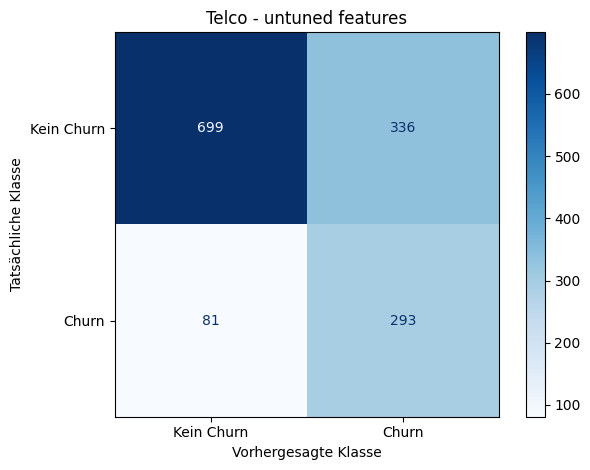

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,30,30,0.7167,0.7040,0.7151


Telco - tuned features
Bestes Alpha: 0.001


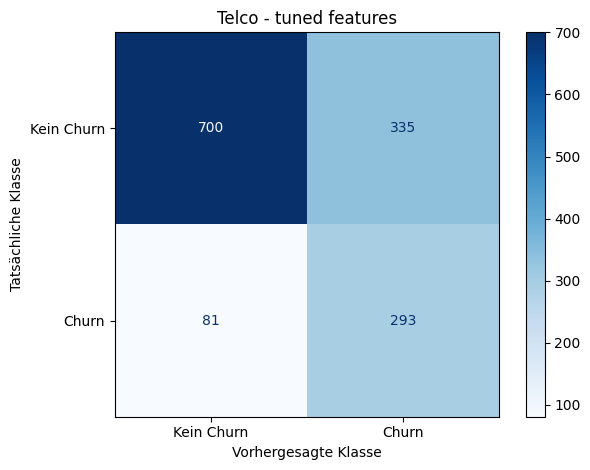

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,30,30,0.7169,0.7048,0.7158


In [ ]:
X_telco = teleco_processed.drop(columns=["Churn"]).to_numpy()
y_telco = teleco_processed["Churn"].to_numpy()

print("Telco - untuned features")
display(run_dataset(X_telco, y_telco, scale=False, display_labels=["Kein Churn", "Churn"], title="Telco - untuned features"))

print("Telco - tuned features")
display(run_dataset_tuned(X_telco, y_telco, display_labels=["Kein Churn", "Churn"], title="Telco - tuned features"))

## 7. Bank results

Bank - untuned features


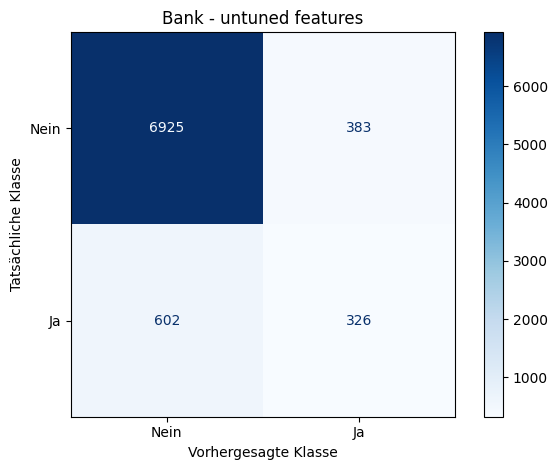

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,46,46,0.8783,0.8804,0.8782


Bank - tuned features
Bestes Alpha: 0.001


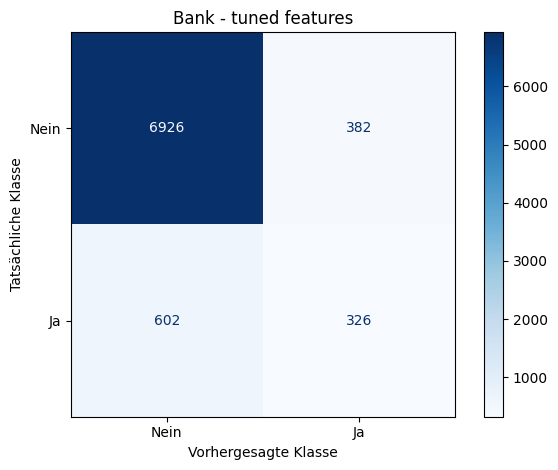

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,46,46,0.8783,0.8805,0.8782


In [ ]:
X_bank = bank_processed.drop(columns=["y"]).to_numpy()
y_bank = bank_processed["y"].to_numpy()

print("Bank - untuned features")
display(run_dataset(X_bank, y_bank, scale=False, display_labels=["No Subscription", "Subscription"], title="Bank - untuned features"))

print("Bank - tuned features")
display(run_dataset_tuned(X_bank, y_bank, display_labels=["No Subscription", "Subscription"], title="Bank - tuned features"))

## 8. E-Commerce results

E-Commerce - untuned features


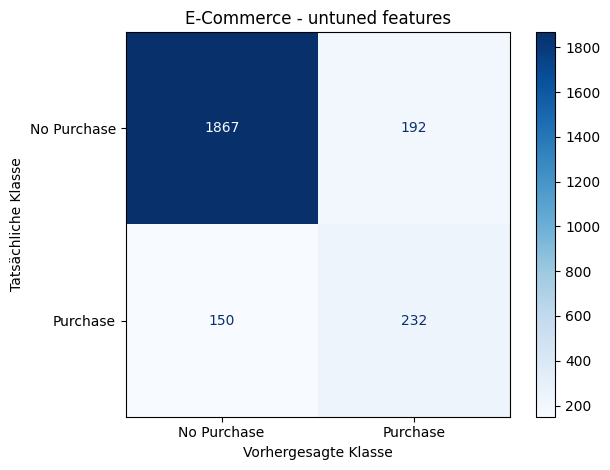

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,26,26,0.8588,0.8599,0.8576


E-Commerce - tuned features
Bestes Alpha: 0.5


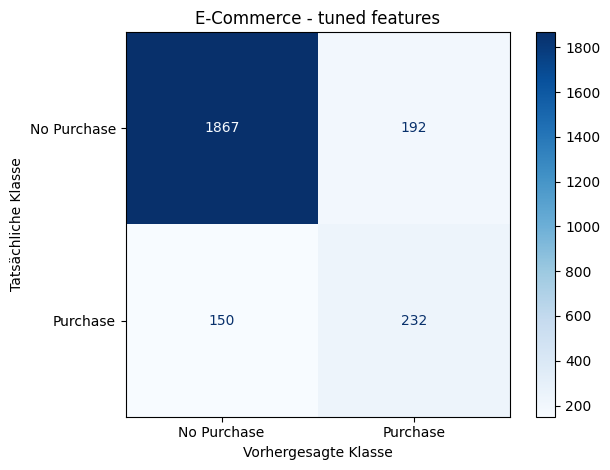

,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
0,26,26,0.8587,0.8599,0.8581


In [12]:
X_ecom = ecom_processed.drop(columns=["Revenue"]).to_numpy()
y_ecom = ecom_processed["Revenue"].to_numpy()

print("E-Commerce - untuned features")
display(run_dataset(X_ecom, y_ecom, scale=False, display_labels=["No Purchase", "Purchase"], title="E-Commerce - untuned features"))

print("E-Commerce - tuned features")
display(run_dataset_tuned(X_ecom, y_ecom, display_labels=["No Purchase", "Purchase"], title="E-Commerce - tuned features"))

## 9. Summary

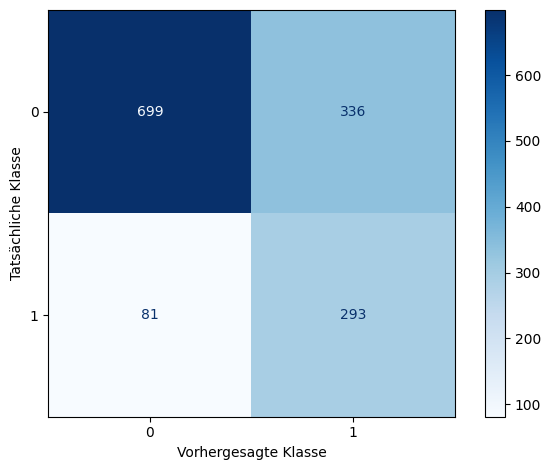

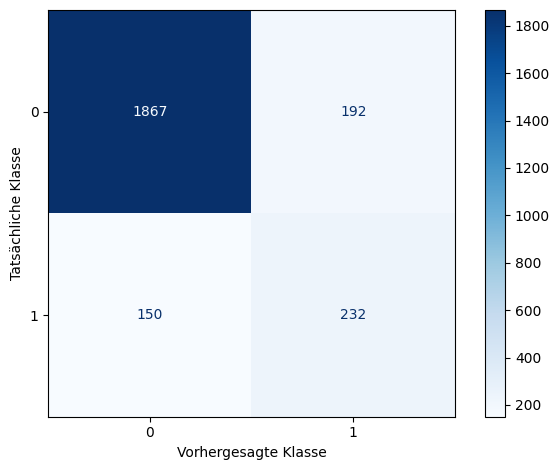

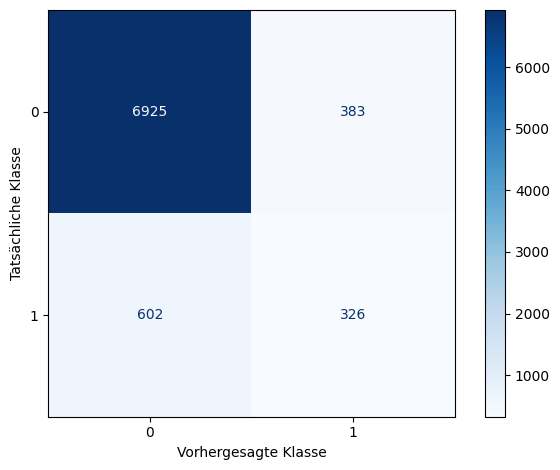

Model Performance Summary (Naive Bayes - CategoricalNB):


,Features,Selected Features,Train Accuracy,Valid Accuracy,Mean CV Score
Dataset,,,,,
Telco Churn,30,30,0.7167,0.7040,0.7151
Online Shoppers,26,26,0.8588,0.8599,0.8576
Bank Marketing,46,46,0.8783,0.8804,0.8782


In [11]:
datasets = [
    ("Telco Churn",     X_telco, y_telco),
    ("Online Shoppers", X_ecom,  y_ecom),
    ("Bank Marketing",  X_bank,  y_bank),
]

summary_rows = []
for name, X, y in datasets:
    row = run_dataset(X, y, scale=False)
    summary_rows.append({
        "Dataset":           name,
        "Features":          int(row["Features"].iloc[0]),
        "Selected Features": int(row["Selected Features"].iloc[0]),
        "Train Accuracy":    row["Train Accuracy"].iloc[0],
        "Valid Accuracy":    row["Valid Accuracy"].iloc[0],
        "Mean CV Score":     row["Mean CV Score"].iloc[0],
    })

summary_df = pd.DataFrame(summary_rows).set_index("Dataset")
print("Model Performance Summary (Naive Bayes - CategoricalNB):")
display(summary_df)